In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d zelihayb/sustainable-energy-and-environmental-data

!unzip -o sustainable-energy-and-environmental-data.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/zelihayb/sustainable-energy-and-environmental-data
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/390k [00:00<?, ?B/s]
100% 390k/390k [00:00<00:00, 793MB/s]
Archive:  sustainable-energy-and-environmental-data.zip
  inflating: energy_data_II.csv      


In [2]:
import pandas as pd
!ls
df = pd.read_csv('energy_data_II.csv')
print(df.columns)
df.head()

energy_data_II.csv  sample_data
kaggle.json	    sustainable-energy-and-environmental-data.zip
Index(['Country Name', 'Country Code', 'Years',
       'Access to clean fuels and technologies for cooking (% of population)',
       'Access to clean fuels and technologies for cooking, rural (% of rural population)',
       'Access to clean fuels and technologies for cooking, urban (% of urban population)',
       'Access to electricity (% of population)',
       'Access to electricity, rural (% of rural population)',
       'Access to electricity, urban (% of urban population)',
       'Adjusted savings: energy depletion (% of GNI)',
       'Alternative and nuclear energy (% of total energy use)',
       'CO2 emissions (kt)', 'CO2 emissions (metric tons per capita)',
       'CO2 emissions from electricity and heat production, total (% of total fuel combustion)',
       'CO2 emissions from gaseous fuel consumption (% of total)',
       'CO2 emissions from gaseous fuel consumption (kt)',
    

,Country Name,Country Code,Years,Access to clean fuels and technologies for cooking (% of population),"Access to clean fuels and technologies for cooking, rural (% of rural population)","Access to clean fuels and technologies for cooking, urban (% of urban population)",Access to electricity (% of population),"Access to electricity, rural (% of rural population)","Access to electricity, urban (% of urban population)",Adjusted savings: energy depletion (% of GNI),...,Population growth (annual %),"Population, female (% of total population)","Population, male","Population, male (% of total population)","Population, total",Public private partnerships investment in energy (current US$),Renewable electricity output (% of total electricity output),Renewable energy consumption (% of total final energy consumption),Time required to get electricity (days),Total greenhouse gas emissions (kt of CO2 equivalent)
0,Afghanistan,AFG,1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.202434,49.990753,5348387.0,50.009247,10694796.0,NaN,67.730496,23.00,NaN,11630.79506
1,Afghanistan,AFG,2000,6.70,1.1,30.5,4.446891,NaN,73.444473,NaN,...,1.443803,49.775111,9815442.0,50.224894,19542982.0,NaN,74.989094,44.99,NaN,14205.32527
2,Afghanistan,AFG,2013,24.30,8.9,75.8,68.040878,60.239198,92.248718,0.073924,...,3.466788,49.442103,15946572.0,50.557897,31541209.0,NaN,78.636408,16.86,114.0,30430.30008
3,Afghanistan,AFG,2014,25.70,9.9,77.6,89.500000,86.500512,98.700000,0.068797,...,3.657576,49.432135,16543889.0,50.567865,32716210.0,NaN,85.323549,18.93,114.0,31165.81580
4,Afghanistan,AFG,2015,27.25,10.9,78.9,71.500000,64.573354,92.500000,0.050390,...,3.121341,49.423184,17071446.0,50.576819,33753499.0,NaN,86.050111,17.53,114.0,31619.07371


In [3]:
import numpy as np
import pandas as pd

# Load data
df = pd.read_csv("energy_data_II.csv")

# Choose only rows with numeric clean fuels value
df = df[pd.to_numeric(df["Access to clean fuels and technologies for cooking (% of population)"], errors='coerce').notnull()]

# We'll use the following features for simplicity
features = [
    "Access to electricity (% of population)",
    "CO2 emissions (metric tons per capita)",
    "GDP per capita growth (annual %)"
]

# Drop rows with any missing values in features/target
df = df.dropna(subset=features + ["Access to clean fuels and technologies for cooking (% of population)"])

# Target: High (1) if clean fuel access >= 80%, else Low (0)
df['High_Clean_Fuel'] = (df["Access to clean fuels and technologies for cooking (% of population)"] >= 80).astype(int)

X = df[features].astype(float).values
y = df['High_Clean_Fuel'].values
y = np.where(y == 1, 1, -1)  # For SVM, labels should be -1/+1

# Optional: Standardize features for better convergence
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

# Train-test split
from sklearn.model_selection import train_test_split  # You can write your own function, if needed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
import numpy as np
import pandas as pd

# Load dataset - replace with your actual path if needed
df = pd.read_csv("energy_data_II.csv")

# Select relevant features - adjust if your dataset has different columns
features = [
    "Access to electricity (% of population)",
    "CO2 emissions (metric tons per capita)",
    "GDP per capita growth (annual %)"
]

# Ensure target column is numeric and drop rows with missing values in features or target
df = df[pd.to_numeric(df["Access to clean fuels and technologies for cooking (% of population)"], errors='coerce').notnull()]
df = df.dropna(subset=features + ["Access to clean fuels and technologies for cooking (% of population)"])

# Create labels: 1 if access >= 80%, else 0
df['High_Clean_Fuel'] = (df["Access to clean fuels and technologies for cooking (% of population)"] >= 80).astype(int)

# Features and target
X = df[features].astype(float).values
y = df['High_Clean_Fuel'].values
y = np.where(y == 1, 1, -1)  # Convert labels to -1 and 1 for SVM

# Standardize features (zero mean, unit variance)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

# Manual train-test split (80-20)
np.random.seed(42)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
split = int(0.8 * len(indices))
train_idx, test_idx = indices[:split], indices[split:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Linear SVM from scratch using SGD
class LinearSVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx in range(n_samples):
                condition = y[idx] * (np.dot(X[idx], self.w) + self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y[idx]*X[idx])
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

# Train and evaluate
svm = LinearSVM(lr=0.001, lambda_param=0.01, n_iters=1000)
svm.fit(X_train, y_train)
predictions = svm.predict(X_test)

# Calculate accuracy
accuracy = np.mean(predictions == y_test)
print(f"Test Accuracy: {accuracy:.3f}")


Test Accuracy: 0.505


SVM Training Accuracy: 0.9795 (97.95%)
SVM Test Accuracy: 0.9676 (96.76%)
SVM Test MSE: 0.0324, MAE: 0.0324
SVM Train MSE: 0.0205, MAE: 0.0205
SVM Test Noise: 0.0318
SVM Train Noise: 0.0203
GENERATING SVM VISUALIZATIONS
--------------------------------------------------


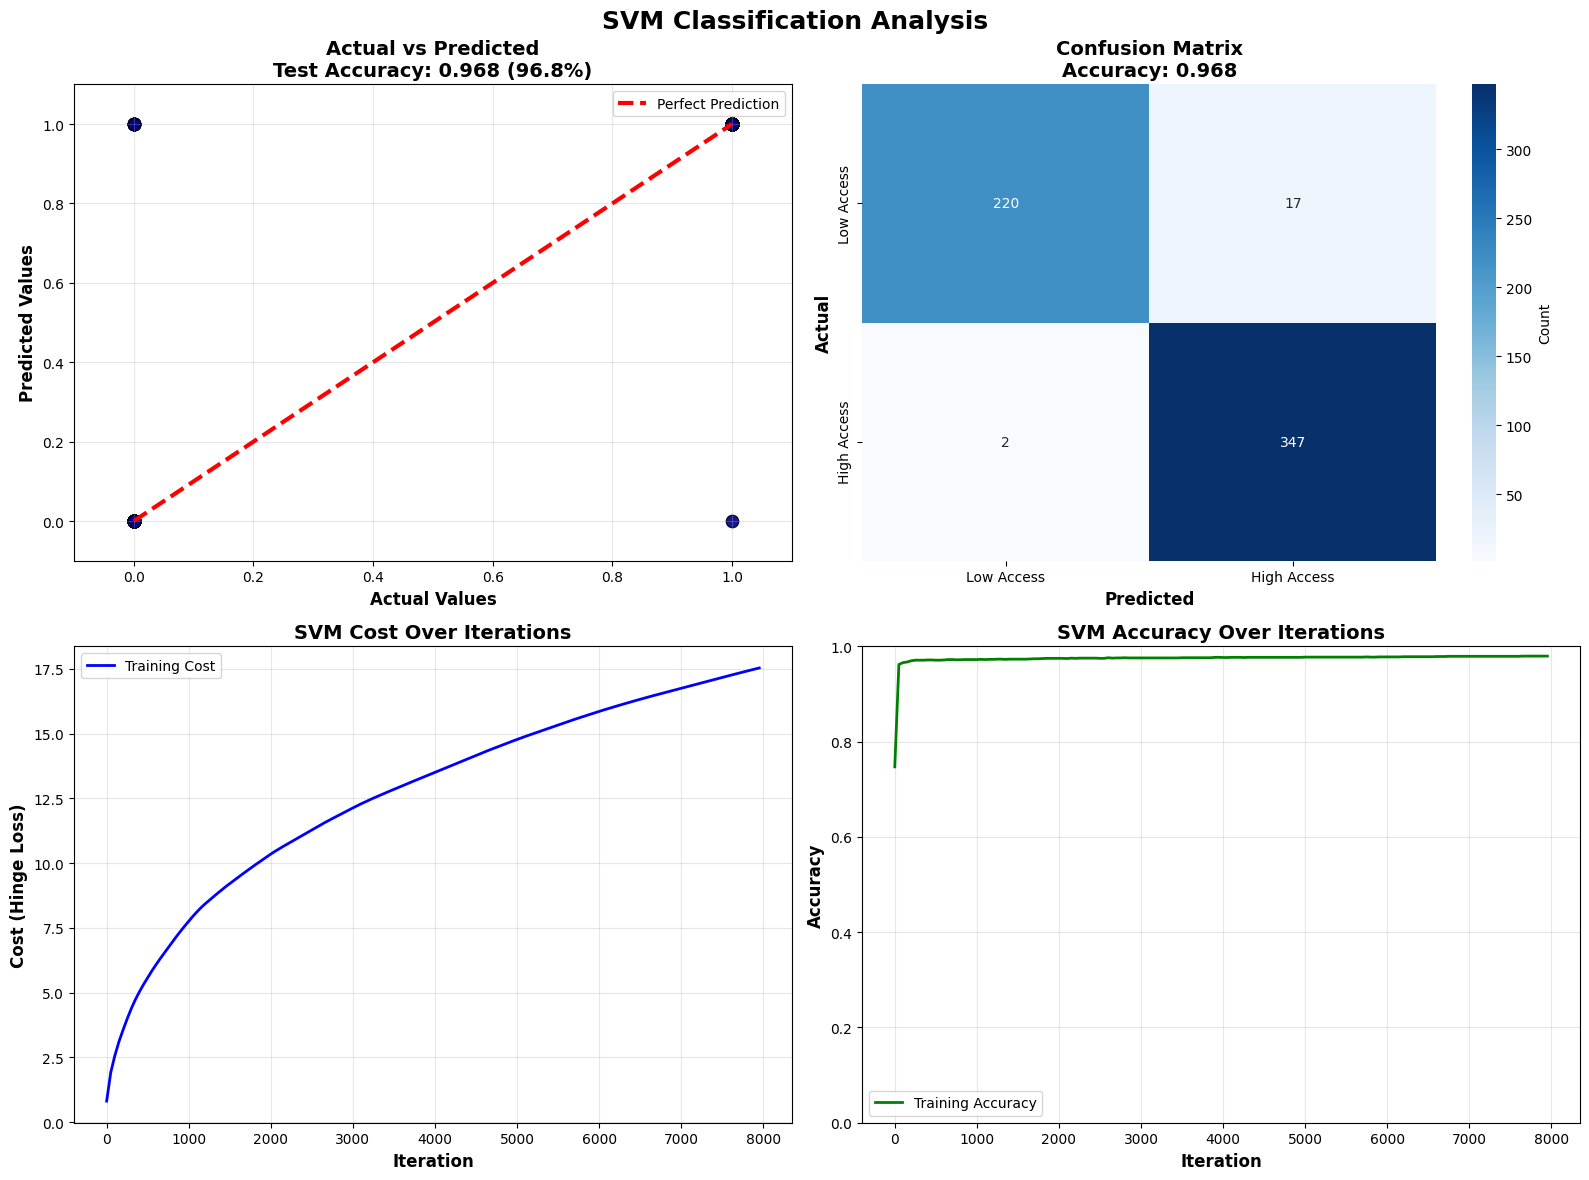

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("energy_data_II.csv")

def preprocess_data(df):
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    df_numeric = df[numeric_columns].copy()
    df_numeric = df_numeric.fillna(df_numeric.median())
    target_column = "Access to clean fuels and technologies for cooking (% of population)"
    features = df_numeric.drop(columns=[target_column])
    target = df_numeric[target_column]
    target_binary = (target >= target.median()).astype(int)
    return features, target_binary, features.columns.tolist(), target_column

class LinearSVM:
    def __init__(self, lr=0.01, lambda_param=0.0001, n_iters=8000, patience=200):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.patience = patience
        self.w = None
        self.b = None
        self.cost_history = []
        self.accuracy_history = []
        self.best_w = None
        self.best_b = None
        self.best_accuracy = 0
        self.wait = 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1)

        self.w = np.random.normal(0, np.sqrt(2.0 / n_features), n_features)
        self.b = 0

        initial_lr = self.lr

        for i in range(self.n_iters):
            current_lr = initial_lr * (1 / (1 + 0.0001 * i))

            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y_[indices]

            batch_size = min(64, n_samples // 4)
            for start_idx in range(0, n_samples, batch_size):
                end_idx = min(start_idx + batch_size, n_samples)
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]

                dw = np.zeros_like(self.w)
                db = 0

                for j in range(len(X_batch)):
                    x_i = X_batch[j]
                    y_i = y_batch[j]

                    condition = y_i * (np.dot(x_i, self.w) + self.b) >= 1
                    if condition:
                        dw += 2 * self.lambda_param * self.w
                    else:
                        dw += 2 * self.lambda_param * self.w - y_i * x_i
                        db += -y_i

                self.w -= current_lr * dw / len(X_batch)
                self.b -= current_lr * db / len(X_batch)

            if i % 50 == 0:
                cost = self.compute_cost(X, y_)
                self.cost_history.append(cost)

                predictions = self.predict(X)
                predictions_binary = np.where(predictions <= 0, -1, 1)
                acc = np.mean(predictions_binary == y_)
                self.accuracy_history.append(acc)

                if acc > self.best_accuracy:
                    self.best_accuracy = acc
                    self.best_w = self.w.copy()
                    self.best_b = self.b
                    self.wait = 0
                else:
                    self.wait += 1
                    if self.wait >= self.patience:
                        print(f"Early stopping at iteration {i}")
                        break

        self.w = self.best_w
        self.b = self.best_b

    def compute_cost(self, X, y):
        n_samples = X.shape[0]
        distances = 1 - y * (np.dot(X, self.w) + self.b)
        distances[distances < 0] = 0
        hinge_loss = np.sum(distances) / n_samples
        cost = 0.5 * np.dot(self.w, self.w) + self.lambda_param * hinge_loss
        return cost

    def predict(self, X):
        return np.dot(X, self.w) + self.b

    def predict_binary(self, X):
        predictions = self.predict(X)
        return np.where(predictions <= 0, 0, 1)

def implement_svm_classification(features, target, feature_names, target_name):
    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, random_state=42, stratify=target
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm_model = LinearSVM(
        lr=0.01,
        lambda_param=0.0001,
        n_iters=8000,
        patience=200
    )
    svm_model.fit(X_train_scaled, y_train)

    train_predictions = svm_model.predict_binary(X_train_scaled)
    test_predictions = svm_model.predict_binary(X_test_scaled)

    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)

    return {
        'svm_model': svm_model,
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'scaler': scaler
    }

def calculate_metrics(results):
    y_test = results['y_test']
    y_train = results['y_train']
    test_pred = results['test_predictions']
    train_pred = results['train_predictions']
    test_acc = results['test_accuracy']
    train_acc = results['train_accuracy']

    test_mse = mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_mse = mean_squared_error(y_train, train_pred)
    train_mae = mean_absolute_error(y_train, train_pred)

    test_noise = np.var(test_pred - (y_test.values if hasattr(y_test, 'values') else y_test))
    train_noise = np.var(train_pred - (y_train.values if hasattr(y_train, 'values') else y_train))

    print(f"SVM Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"SVM Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"SVM Test MSE: {test_mse:.4f}, MAE: {test_mae:.4f}")
    print(f"SVM Train MSE: {train_mse:.4f}, MAE: {train_mae:.4f}")
    print(f"SVM Test Noise: {test_noise:.4f}")
    print(f"SVM Train Noise: {train_noise:.4f}")

    return {
        'test_metrics': {'accuracy': test_acc, 'mse': test_mse, 'mae': test_mae, 'noise': test_noise},
        'train_metrics': {'accuracy': train_acc, 'mse': train_mse, 'mae': train_mae, 'noise': train_noise}
    }

def create_visualizations(results, metrics):
    print("GENERATING SVM VISUALIZATIONS")
    print("-" * 50)

    plt.style.use('default')
    sns.set_palette("viridis")

    y_test = results['y_test']
    predictions = results['test_predictions']
    accuracy = metrics['test_metrics']['accuracy']
    svm_model = results['svm_model']

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('SVM Classification Analysis', fontsize=18, fontweight='bold')

    axes[0,0].scatter(y_test, predictions, alpha=0.7, color='darkblue', edgecolors='black', linewidth=0.8, s=80)
    axes[0,0].plot([0, 1], [0, 1], 'r--', linewidth=3, label='Perfect Prediction')
    axes[0,0].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
    axes[0,0].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
    axes[0,0].set_title(f'Actual vs Predicted\nTest Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)',
                       fontsize=14, fontweight='bold')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].legend()
    axes[0,0].set_xlim(-0.1, 1.1)
    axes[0,0].set_ylim(-0.1, 1.1)

    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
                xticklabels=['Low Access', 'High Access'],
                yticklabels=['Low Access', 'High Access'],
                cbar_kws={'label': 'Count'})
    axes[0,1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
    axes[0,1].set_ylabel('Actual', fontsize=12, fontweight='bold')
    axes[0,1].set_title(f'Confusion Matrix\nAccuracy: {accuracy:.3f}', fontsize=14, fontweight='bold')

    if len(svm_model.cost_history) > 0:
        iterations = range(0, len(svm_model.cost_history) * 50, 50)
        axes[1,0].plot(iterations, svm_model.cost_history, 'b-', linewidth=2, label='Training Cost')
        axes[1,0].set_xlabel('Iteration', fontsize=12, fontweight='bold')
        axes[1,0].set_ylabel('Cost (Hinge Loss)', fontsize=12, fontweight='bold')
        axes[1,0].set_title('SVM Cost Over Iterations', fontsize=14, fontweight='bold')
        axes[1,0].grid(True, alpha=0.3)
        axes[1,0].legend()

    if len(svm_model.accuracy_history) > 0:
        iterations = range(0, len(svm_model.accuracy_history) * 50, 50)
        axes[1,1].plot(iterations, svm_model.accuracy_history, 'g-', linewidth=2, label='Training Accuracy')
        axes[1,1].set_xlabel('Iteration', fontsize=12, fontweight='bold')
        axes[1,1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
        axes[1,1].set_title('SVM Accuracy Over Iterations', fontsize=14, fontweight='bold')
        axes[1,1].grid(True, alpha=0.3)
        axes[1,1].legend()
        axes[1,1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

features, target, feature_names, target_name = preprocess_data(df)
results = implement_svm_classification(features, target, feature_names, target_name)
metrics = calculate_metrics(results)
create_visualizations(results, metrics)



=== SVM ROC Curve Analysis ===
--------------------------------------------------
Training AUC: 0.9958
Testing AUC: 0.9939
Training Average Precision: 0.9968
Testing Average Precision: 0.9954


ValueError: Axis limits cannot be NaN or Inf

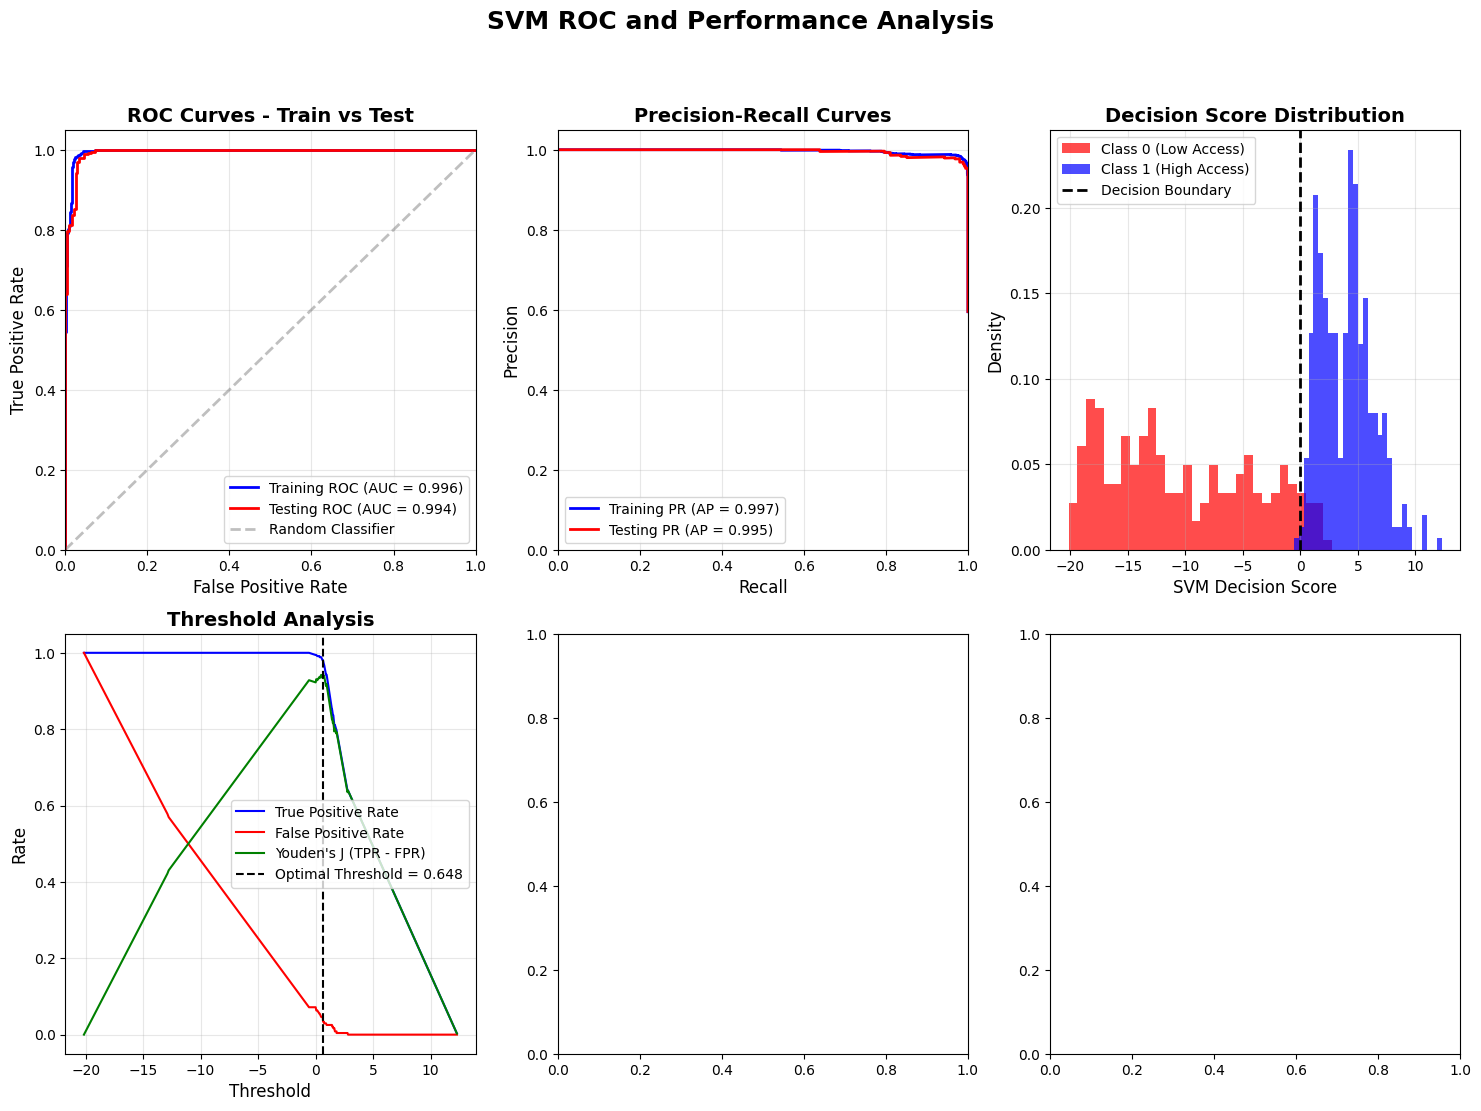

In [6]:
# CELL 6: ROC Curve Analysis for SVM
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
import seaborn as sns

def plot_roc_curves(results, metrics):
    """
    Generate comprehensive ROC curve analysis for SVM model
    """
    print("=== SVM ROC Curve Analysis ===")
    print("-" * 50)

    # Get the trained SVM model and test data
    svm_model = results['svm_model']
    X_test = results['X_test']
    y_test = results['y_test']
    X_train = results['X_train']
    y_train = results['y_train']

    # Get decision function scores (distance from hyperplane)
    # Positive scores indicate class 1, negative scores indicate class 0
    y_test_scores = svm_model.predict(X_test)
    y_train_scores = svm_model.predict(X_train)

    # Calculate ROC curve for test set
    fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_scores)
    auc_test = roc_auc_score(y_test, y_test_scores)

    # Calculate ROC curve for training set
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_scores)
    auc_train = roc_auc_score(y_train, y_train_scores)

    # Calculate Precision-Recall curves
    precision_test, recall_test, pr_thresholds_test = precision_recall_curve(y_test, y_test_scores)
    precision_train, recall_train, pr_thresholds_train = precision_recall_curve(y_train, y_train_scores)

    ap_test = average_precision_score(y_test, y_test_scores)
    ap_train = average_precision_score(y_train, y_train_scores)

    # Print AUC scores
    print(f"Training AUC: {auc_train:.4f}")
    print(f"Testing AUC: {auc_test:.4f}")
    print(f"Training Average Precision: {ap_train:.4f}")
    print(f"Testing Average Precision: {ap_test:.4f}")

    # Create comprehensive visualization
    plt.style.use('default')
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('SVM ROC and Performance Analysis', fontsize=18, fontweight='bold')

    # 1. ROC Curve Comparison (Train vs Test)
    axes[0,0].plot(fpr_train, tpr_train, color='blue', lw=2,
                   label=f'Training ROC (AUC = {auc_train:.3f})')
    axes[0,0].plot(fpr_test, tpr_test, color='red', lw=2,
                   label=f'Testing ROC (AUC = {auc_test:.3f})')
    axes[0,0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
                   alpha=0.5, label='Random Classifier')
    axes[0,0].set_xlim([0.0, 1.0])
    axes[0,0].set_ylim([0.0, 1.05])
    axes[0,0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0,0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0,0].set_title('ROC Curves - Train vs Test', fontsize=14, fontweight='bold')
    axes[0,0].legend(loc="lower right")
    axes[0,0].grid(True, alpha=0.3)

    # 2. Precision-Recall Curves
    axes[0,1].plot(recall_train, precision_train, color='blue', lw=2,
                   label=f'Training PR (AP = {ap_train:.3f})')
    axes[0,1].plot(recall_test, precision_test, color='red', lw=2,
                   label=f'Testing PR (AP = {ap_test:.3f})')
    axes[0,1].set_xlim([0.0, 1.0])
    axes[0,1].set_ylim([0.0, 1.05])
    axes[0,1].set_xlabel('Recall', fontsize=12)
    axes[0,1].set_ylabel('Precision', fontsize=12)
    axes[0,1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
    axes[0,1].legend(loc="lower left")
    axes[0,1].grid(True, alpha=0.3)

    # 3. Decision Score Distribution
    axes[0,2].hist(y_test_scores[y_test == 0], bins=30, alpha=0.7,
                   label='Class 0 (Low Access)', color='red', density=True)
    axes[0,2].hist(y_test_scores[y_test == 1], bins=30, alpha=0.7,
                   label='Class 1 (High Access)', color='blue', density=True)
    axes[0,2].axvline(x=0, color='black', linestyle='--', linewidth=2,
                      label='Decision Boundary')
    axes[0,2].set_xlabel('SVM Decision Score', fontsize=12)
    axes[0,2].set_ylabel('Density', fontsize=12)
    axes[0,2].set_title('Decision Score Distribution', fontsize=14, fontweight='bold')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)

    # 4. Threshold Analysis
    # Find optimal threshold using Youden's J statistic
    j_scores = tpr_test - fpr_test
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = thresholds_test[optimal_idx]
    optimal_fpr = fpr_test[optimal_idx]
    optimal_tpr = tpr_test[optimal_idx]

    axes[1,0].plot(thresholds_test, tpr_test, color='blue', label='True Positive Rate')
    axes[1,0].plot(thresholds_test, fpr_test, color='red', label='False Positive Rate')
    axes[1,0].plot(thresholds_test, tpr_test - fpr_test, color='green',
                   label="Youden's J (TPR - FPR)")
    axes[1,0].axvline(x=optimal_threshold, color='black', linestyle='--',
                      label=f'Optimal Threshold = {optimal_threshold:.3f}')
    axes[1,0].set_xlabel('Threshold', fontsize=12)
    axes[1,0].set_ylabel('Rate', fontsize=12)
    axes[1,0].set_title('Threshold Analysis', fontsize=14, fontweight='bold')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].set_xlim([thresholds_test.min(), thresholds_test.max()])

    # 5. ROC Curve with Optimal Point
    axes[1,1].plot(fpr_test, tpr_test, color='darkorange', lw=2,
                   label=f'ROC curve (AUC = {auc_test:.3f})')
    axes[1,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                   label='Random Classifier')
    axes[1,1].plot(optimal_fpr, optimal_tpr, marker='o', markersize=10,
                   color='red', label=f'Optimal Point\n(FPR={optimal_fpr:.3f}, TPR={optimal_tpr:.3f})')
    axes[1,1].set_xlim([0.0, 1.0])
    axes[1,1].set_ylim([0.0, 1.05])
    axes[1,1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1,1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1,1].set_title('ROC Curve with Optimal Threshold', fontsize=14, fontweight='bold')
    axes[1,1].legend(loc="lower right")
    axes[1,1].grid(True, alpha=0.3)

    # 6. Performance Metrics Comparison
    metrics_data = {
        'Metric': ['AUC', 'Average Precision', 'Accuracy', 'Optimal TPR', 'Optimal FPR'],
        'Training': [auc_train, ap_train, metrics['train_metrics']['accuracy'],
                    tpr_train[np.argmax(tpr_train - fpr_train)],
                    fpr_train[np.argmax(tpr_train - fpr_train)]],
        'Testing': [auc_test, ap_test, metrics['test_metrics']['accuracy'],
                   optimal_tpr, optimal_fpr]
    }

    x = np.arange(len(metrics_data['Metric']))
    width = 0.35

    axes[1,2].bar(x - width/2, metrics_data['Training'], width,
                  label='Training', color='blue', alpha=0.7)
    axes[1,2].bar(x + width/2, metrics_data['Testing'], width,
                  label='Testing', color='red', alpha=0.7)
    axes[1,2].set_xlabel('Metrics', fontsize=12)
    axes[1,2].set_ylabel('Score', fontsize=12)
    axes[1,2].set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
    axes[1,2].set_xticks(x)
    axes[1,2].set_xticklabels(metrics_data['Metric'], rotation=45, ha='right')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3)
    axes[1,2].set_ylim(0, 1.1)

    # Add value labels on bars
    for i, (train_val, test_val) in enumerate(zip(metrics_data['Training'], metrics_data['Testing'])):
        axes[1,2].text(i - width/2, train_val + 0.01, f'{train_val:.3f}',
                       ha='center', va='bottom', fontsize=10)
        axes[1,2].text(i + width/2, test_val + 0.01, f'{test_val:.3f}',
                       ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print detailed analysis
    print(f"\n=== ROC Curve Interpretation ===")

    if auc_test >= 0.9:
        interpretation = "Excellent"
    elif auc_test >= 0.8:
        interpretation = "Good"
    elif auc_test >= 0.7:
        interpretation = "Fair"
    elif auc_test >= 0.6:
        interpretation = "Poor"
    else:
        interpretation = "Very Poor"

    print(f"Model Performance: {interpretation}")
    print(f"Test AUC Score: {auc_test:.4f}")
    print(f"Training AUC Score: {auc_train:.4f}")
    print(f"Overfitting Check: {abs(auc_train - auc_test):.4f} {'(Overfitting detected)' if abs(auc_train - auc_test) > 0.1 else '(Good generalization)'}")

    print(f"\nOptimal Threshold Analysis:")
    print(f"Optimal Threshold: {optimal_threshold:.4f}")
    print(f"At optimal threshold:")
    print(f"  - True Positive Rate: {optimal_tpr:.4f}")
    print(f"  - False Positive Rate: {optimal_fpr:.4f}")
    print(f"  - Youden's J Score: {optimal_tpr - optimal_fpr:.4f}")

    return {
        'auc_train': auc_train,
        'auc_test': auc_test,
        'ap_train': ap_train,
        'ap_test': ap_test,
        'optimal_threshold': optimal_threshold,
        'optimal_tpr': optimal_tpr,
        'optimal_fpr': optimal_fpr,
        'test_scores': y_test_scores,
        'train_scores': y_train_scores
    }

# Generate ROC analysis
roc_results = plot_roc_curves(results, metrics)


=== Multi-Model ROC Comparison ===
--------------------------------------------------


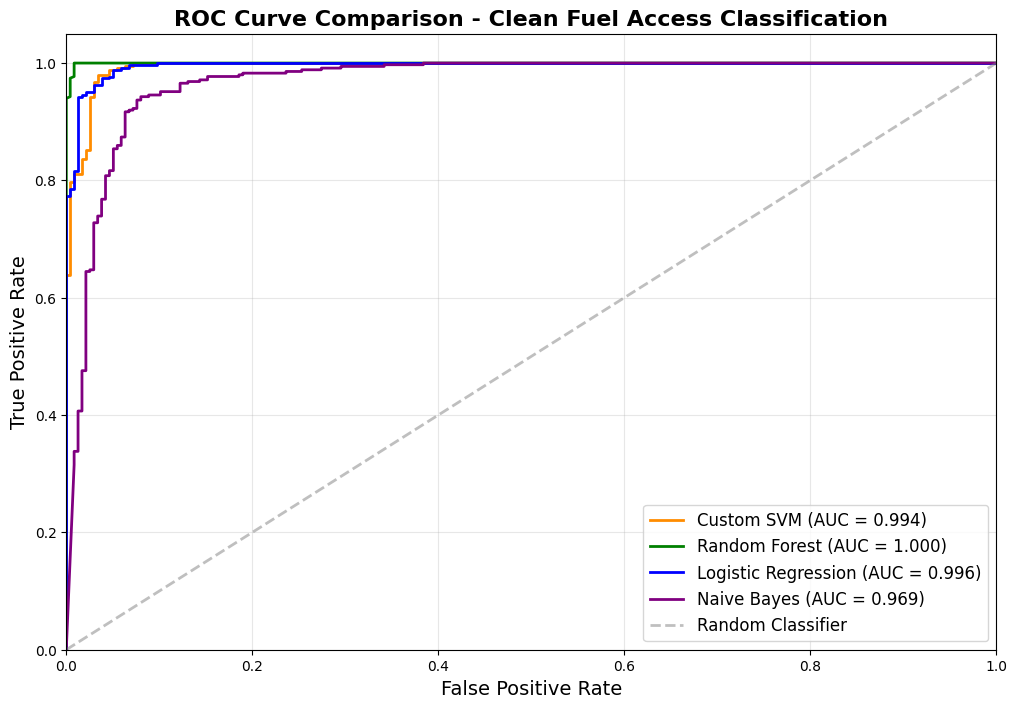


=== Model Performance Ranking ===
1. Random Forest: AUC = 0.9996
2. Logistic Regression: AUC = 0.9956
3. Custom SVM: AUC = 0.9939
4. Naive Bayes: AUC = 0.9687

Best performing model: Random Forest with AUC = 0.9996


In [7]:
# CELL 7: ROC Curve Comparison with Multiple Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

def compare_models_roc(results):
    """
    Compare SVM with other sklearn models using ROC curves
    """
    print("=== Multi-Model ROC Comparison ===")
    print("-" * 50)

    X_train = results['X_train']
    X_test = results['X_test']
    y_train = results['y_train']
    y_test = results['y_test']
    svm_model = results['svm_model']

    # Initialize other models
    models = {
        'Custom SVM': svm_model,
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Naive Bayes': GaussianNB()
    }

    # Train sklearn models
    for name, model in models.items():
        if name != 'Custom SVM':
            model.fit(X_train, y_train)

    # Plot ROC curves for all models
    plt.figure(figsize=(12, 8))
    colors = ['darkorange', 'green', 'blue', 'purple']

    auc_scores = {}

    for i, (name, model) in enumerate(models.items()):
        if name == 'Custom SVM':
            # Use decision function for custom SVM
            y_scores = model.predict(X_test)
        else:
            # Use predict_proba for sklearn models
            if hasattr(model, "predict_proba"):
                y_scores = model.predict_proba(X_test)[:, 1]
            else:
                y_scores = model.decision_function(X_test)

        fpr, tpr, _ = roc_curve(y_test, y_scores)
        auc = roc_auc_score(y_test, y_scores)
        auc_scores[name] = auc

        plt.plot(fpr, tpr, color=colors[i], lw=2,
                label=f'{name} (AUC = {auc:.3f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--',
             alpha=0.5, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('ROC Curve Comparison - Clean Fuel Access Classification', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print model rankings
    print(f"\n=== Model Performance Ranking ===")
    sorted_scores = sorted(auc_scores.items(), key=lambda x: x[1], reverse=True)
    for i, (model_name, score) in enumerate(sorted_scores, 1):
        print(f"{i}. {model_name}: AUC = {score:.4f}")

    print(f"\nBest performing model: {sorted_scores[0][0]} with AUC = {sorted_scores[0][1]:.4f}")

    return auc_scores

# Run model comparison
model_comparison = compare_models_roc(results)
